# Iris Flower Species Classification Using Machine Learning

## Project Overview

This project develops a machine learning classification system to predict Iris flower species from four morphological features:

- Sepal length
- Sepal width
- Petal length
- Petal width

The target classes are:

- Iris setosa
- Iris versicolor
- Iris virginica

The project compares a simple baseline with Logistic Regression and Support Vector Machine (SVM), followed by hyperparameter tuning, evaluation, and failure analysis.

## Objective

The objective of this project is to build and evaluate machine learning models
for classifying Iris flower species based on four morphological features.

The main goals are:

1. Inspect and clean the dataset.
2. Perform exploratory data analysis (EDA).
3. Establish a simple baseline model.
4. Train and compare Logistic Regression and Support Vector Machine (SVM).
5. Evaluate the models using accuracy, precision, recall, and F1-score.
6. Perform hyperparameter tuning using cross-validation.
7. Analyze model failures and limitations.
8. Select the best-performing model based on held-out test performance.

In [10]:
# ==========================================
# Step 1: Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


## Dataset Description

The Iris dataset contains 150 samples belonging to three Iris flower species:

- Iris setosa
- Iris versicolor
- Iris virginica

Each sample contains four numerical features measured in centimeters:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

Each species contains 50 samples, making the dataset balanced across the three classes.

The target variable represents the Iris flower species that the model will predict.

In [11]:
# ==========================================
# Step 2: Create DataFrame
# ==========================================

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species name
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
# ==========================================
# Step 3: Basic Dataset Information
# ==========================================

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [13]:
# ==========================================
# Step 4: Statistical Summary
# ==========================================

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Data Cleaning and Inspection

The dataset was inspected to understand its structure and data quality.

The following checks were performed:

- Dataset shape and information
- Statistical summary of numerical features
- Missing value detection
- Duplicate row detection
- Class distribution analysis

These checks help ensure that the dataset is suitable for machine learning.

In [14]:
# ==========================================
# Step 5: Missing Value Check
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [15]:
# ==========================================
# Step 6: Duplicate Check
# ==========================================

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [16]:
# ==========================================
# Step 7: Class Distribution
# ==========================================

print("Class Distribution:")
print(df["species"].value_counts())

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to better understand the
distribution and relationships of the Iris flower features.

The analysis includes:

- Feature distributions
- Species distribution
- Relationships between features
- Feature correlation
- Potential outliers

These visualizations help identify patterns and understand how the three
Iris species differ based on their measurements.

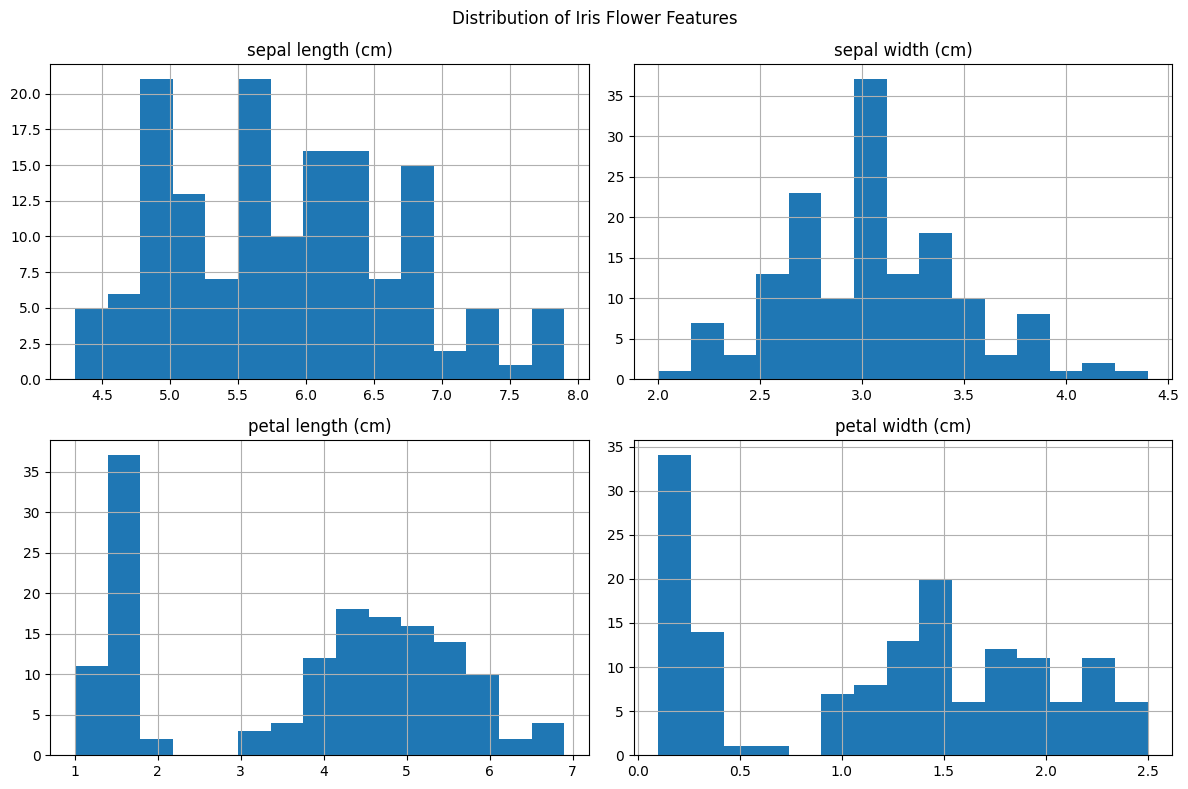

In [17]:
# ==========================================
# Step 8: Feature Distribution
# ==========================================

features = iris.feature_names

df[features].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribution of Iris Flower Features")
plt.tight_layout()
plt.show()

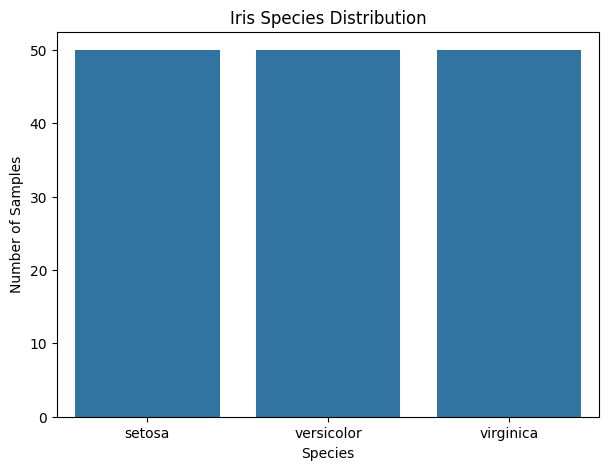

In [18]:
# ==========================================
# Step 9: Species Distribution
# ==========================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.show()

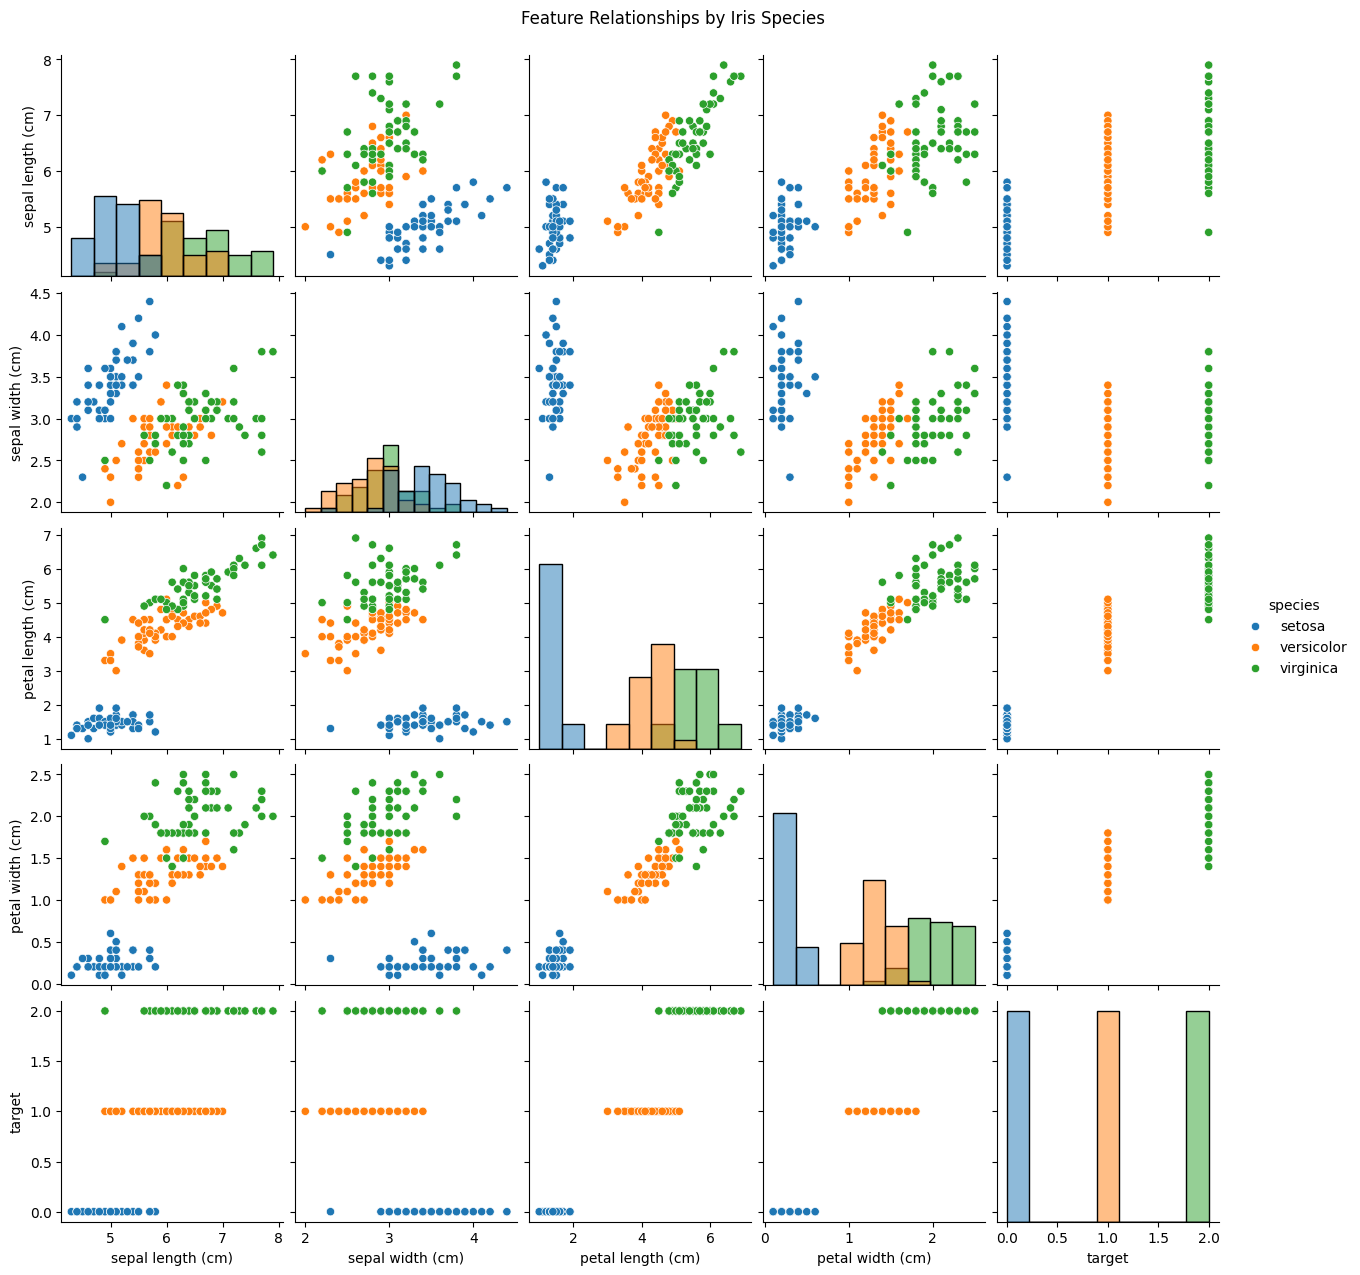

In [19]:
# ==========================================
# Step 10: Feature Relationship
# ==========================================

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Feature Relationships by Iris Species",
    y=1.02
)

plt.show()

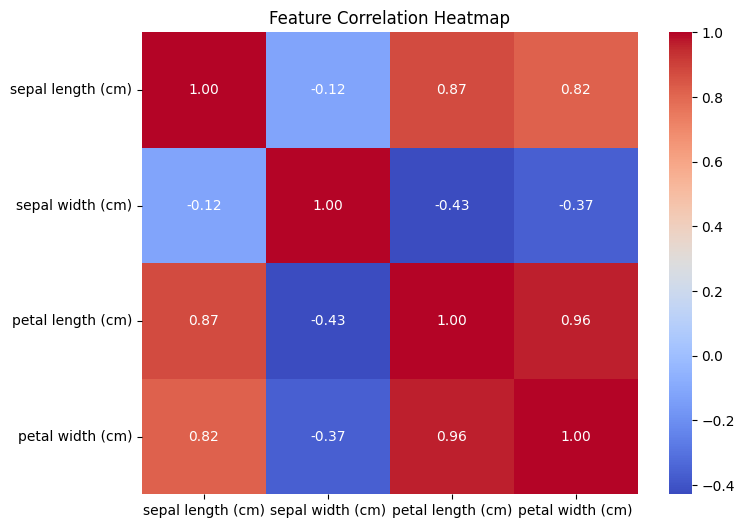

In [20]:
# ==========================================
# Step 11: Correlation Analysis
# ==========================================

plt.figure(figsize=(8, 6))

correlation = df[features].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

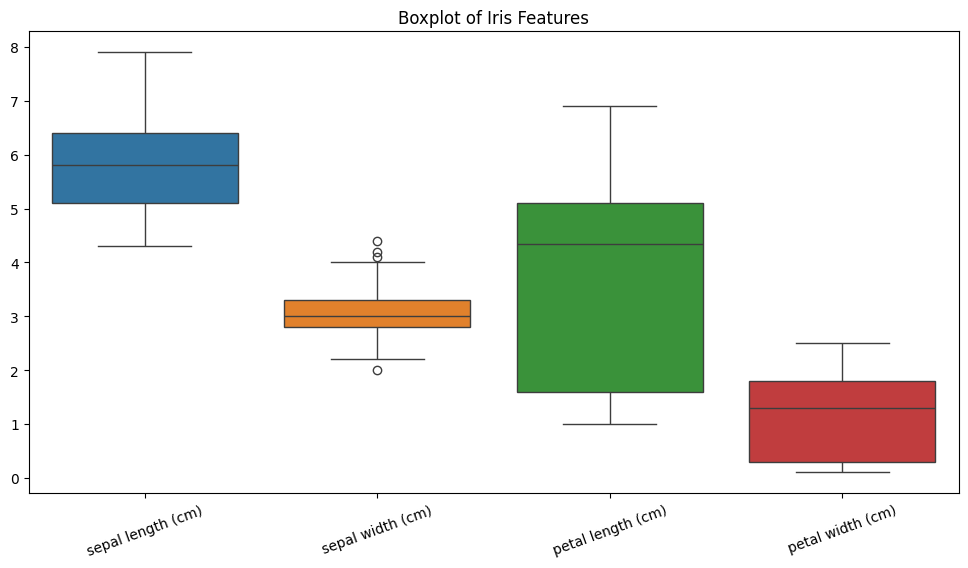

In [21]:
# ==========================================
# Step 12: Outlier Analysis
# ==========================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[features]
)

plt.title("Boxplot of Iris Features")
plt.xticks(rotation=20)
plt.show()

## Data Preparation

The four numerical features were used as input variables, while the target
variable represents the Iris species.

The dataset was divided into:

- 80% training data
- 20% held-out test data

Stratified splitting was used to preserve the class distribution in both
training and test sets.

Feature scaling was performed using StandardScaler. The scaler was fitted
only on the training data and then applied to the test data to prevent data
leakage.

In [22]:
# ==========================================
# Step 13: Separate Features and Target
# ==========================================

X = df[features]
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [23]:
# ==========================================
# Step 14: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [24]:
# ==========================================
# Step 15: Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [25]:
scaler.fit_transform(X_train)

array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575],
       [ 0.54731923, -1.22765467,  0.69841284,  0.91510102],
       [-0.2885865 , -0.77987789,  0.24416059,  0.12508575],
       [ 0.54731923, -0.5559895 ,  0.75519438,  0.38842418],
       [ 2.21913069, -0.10821272,  1.3230097 ,  1.44177787],
       [ 2.21913069,  1.6828944 ,  1.66369889,  1.31010866],
       [ 2.09971558, -0.10821272,  1.60691736,  1.17843945],
       [ 0.18907392, -0.33210111,  0.41450518,  0.38842418],
       [-1.00507713, -2.34709662, -0.15331014, -0.26992188],
       [-0.04975629, -0.77987789,  0.18737906, -0.26992188],
       [-0.04975629, -1.00376628,  0.13059752, -0.00658346],
       [-1.36332244,  0.33956406, -1.23215924, -1.32327558],
       [-0.88566202,  1.

In [26]:
scaler.transform(X_test)

array([[-1.72156775, -0.10821272, -1.40250384, -1.32327558],
       [ 0.30848902, -0.10821272,  0.64163131,  0.78343181],
       [-1.12449223, -1.45154306, -0.2668732 , -0.26992188],
       [-1.00507713, -1.67543145, -0.2668732 , -0.26992188],
       [-1.72156775,  0.33956406, -1.40250384, -1.32327558],
       [ 0.54731923,  0.56345245,  0.52806825,  0.52009339],
       [-1.48273754,  1.23511762, -1.57284844, -1.32327558],
       [-0.52741671,  0.78734084, -1.17537771, -1.32327558],
       [ 0.78614944, -0.10821272,  0.81197591,  1.04677024],
       [-0.52741671, -0.10821272,  0.41450518,  0.38842418],
       [ 1.74147027, -0.33210111,  1.43657276,  0.78343181],
       [ 1.26380985,  0.11567567,  0.75519438,  1.44177787],
       [ 0.78614944, -0.10821272,  1.1526651 ,  1.31010866],
       [ 0.66673433,  0.33956406,  0.41450518,  0.38842418],
       [-1.00507713,  0.78734084, -1.28894078, -1.32327558],
       [-1.00507713,  0.56345245, -1.34572231, -1.32327558],
       [-0.04975629,  2.

In [27]:
# ==========================================
# Step 16: Check Scaled Data
# ==========================================

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

First 5 scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


## Model Development

Three classification approaches were evaluated in this project:

1. Dummy Classifier — used as a simple baseline.
2. Logistic Regression — used as a linear classification model.
3. Support Vector Machine (SVM) — used as the main machine learning model.

The models were trained using the training set and evaluated on the held-out
test set.

In [28]:
# ==========================================
# Step 17: Baseline Model
# ==========================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.3333333333333333


In [29]:
# ==========================================
# Step 18: Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


In [30]:
# ==========================================
# Step 19: Support Vector Machine
# ==========================================

from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9666666666666667


In [31]:
# ==========================================
# Step 20: Model Comparison
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        svm_accuracy
    ]
})

results

,Model,Accuracy
0,Dummy Baseline,0.333333
1,Logistic Regression,0.933333
2,SVM,0.966667


## Model Evaluation

The trained models were evaluated on the held-out test set using multiple
classification metrics.

The evaluation metrics used were:

- Accuracy
- Precision
- Recall
- F1-score

A confusion matrix was also used to examine class-level prediction errors.

The results of the baseline and machine learning models were compared to
identify the best-performing approach.

In [33]:
# ==========================================
# Step 21: Model Evaluation in Percentage
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Function to calculate metrics
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(
        y_true, y_pred, average="macro"
    ) * 100
    recall = recall_score(
        y_true, y_pred, average="macro"
    ) * 100
    f1 = f1_score(
        y_true, y_pred, average="macro"
    ) * 100

    print(f"\n========== {model_name} ==========")
    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Precision : {precision:.2f}%")
    print(f"Recall    : {recall:.2f}%")
    print(f"F1-Score  : {f1:.2f}%")

    return accuracy, precision, recall, f1


# Evaluate Logistic Regression
logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)

# Evaluate SVM
svm_metrics = evaluate_model(
    "SVM",
    y_test,
    svm_pred
)


========== Logistic Regression ==========
Accuracy  : 93.33%
Precision : 93.33%
Recall    : 93.33%
F1-Score  : 93.33%

========== SVM ==========
Accuracy  : 96.67%
Precision : 96.97%
Recall    : 96.67%
F1-Score  : 96.66%


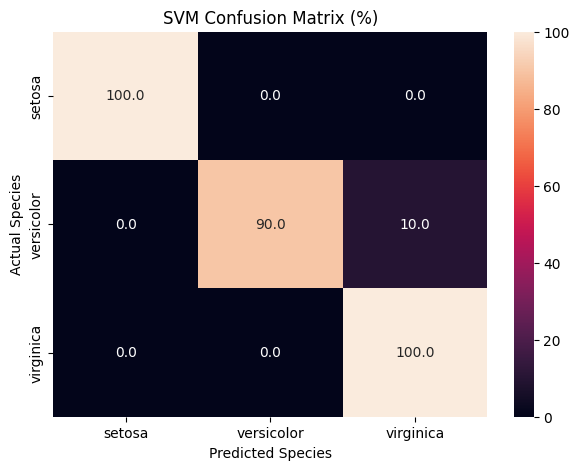

In [34]:
# ==========================================
# Step 22: SVM Confusion Matrix (%)
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, svm_pred)

# Convert each row into percentage
cm_percentage = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percentage,
    annot=True,
    fmt=".1f",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("SVM Confusion Matrix (%)")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

## Failure Analysis

The final SVM model made one incorrect prediction on the held-out test set.

The misclassified sample had the following details:

- Actual class: Iris versicolor
- Predicted class: Iris virginica
- Sepal length: 6.70 cm
- Sepal width: 3.00 cm
- Petal length: 5.00 cm
- Petal width: 1.70 cm

This shows that the model had difficulty distinguishing one Versicolor
sample from Virginica.

In [35]:
# ==========================================
# Step 23: Failure Analysis
# ==========================================

# Find incorrect predictions
incorrect_mask = y_test != svm_pred

# Get incorrect samples
failed_samples = X_test[incorrect_mask].copy()

# Add actual and predicted labels
failed_samples["actual"] = y_test[incorrect_mask]
failed_samples["predicted"] = svm_pred[incorrect_mask]

# Convert numeric labels to species names
failed_samples["actual_species"] = failed_samples["actual"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

failed_samples["predicted_species"] = failed_samples["predicted"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("Number of incorrect predictions:", len(failed_samples))

failed_samples

Number of incorrect predictions: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual,predicted,actual_species,predicted_species
77,6.7,3.0,5.0,1.7,1,2,versicolor,virginica


In [36]:
# ==========================================
# Failure Summary
# ==========================================

for index, row in failed_samples.iterrows():

    print(f"Sample Index: {index}")
    print(f"Actual Species: {row['actual_species']}")
    print(f"Predicted Species: {row['predicted_species']}")

    print("\nFeature Values:")
    print(f"Sepal Length : {row['sepal length (cm)']:.2f} cm")
    print(f"Sepal Width  : {row['sepal width (cm)']:.2f} cm")
    print(f"Petal Length : {row['petal length (cm)']:.2f} cm")
    print(f"Petal Width  : {row['petal width (cm)']:.2f} cm")

    print("-" * 40)

Sample Index: 77
Actual Species: versicolor
Predicted Species: virginica

Feature Values:
Sepal Length : 6.70 cm
Sepal Width  : 3.00 cm
Petal Length : 5.00 cm
Petal Width  : 1.70 cm
----------------------------------------


## Hyperparameter Tuning

Since the original SVM achieved the best initial held-out test performance,
SVM was selected for hyperparameter tuning.

GridSearchCV with 5-fold cross-validation was used to evaluate different
combinations of:

- C
- Kernel
- Gamma

The best parameter combination was:

- C = 0.1
- Kernel = linear
- Gamma = scale

The best cross-validation accuracy was 97.50%.

However, the tuned SVM achieved 93.33% accuracy on the held-out test set,
while the original SVM achieved 96.67%.

Therefore, the original SVM was retained as the final model based on its
better held-out test performance.

In [37]:
# ==========================================
# Step 24: SVM Hyperparameter Tuning
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Create pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

# Hyperparameter grid
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"]
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_ * 100:.2f}%")

Best Parameters:
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Best Cross-Validation Accuracy:
97.50%


In [38]:
# ==========================================
# Step 25: Evaluate Tuned SVM
# ==========================================

best_svm = grid_search.best_estimator_

# Predict on held-out test set
tuned_svm_pred = best_svm.predict(X_test)

# Calculate metrics
tuned_accuracy = accuracy_score(
    y_test,
    tuned_svm_pred
) * 100

tuned_precision = precision_score(
    y_test,
    tuned_svm_pred,
    average="macro"
) * 100

tuned_recall = recall_score(
    y_test,
    tuned_svm_pred,
    average="macro"
) * 100

tuned_f1 = f1_score(
    y_test,
    tuned_svm_pred,
    average="macro"
) * 100

print("========== Tuned SVM ==========")
print(f"Accuracy  : {tuned_accuracy:.2f}%")
print(f"Precision : {tuned_precision:.2f}%")
print(f"Recall    : {tuned_recall:.2f}%")
print(f"F1-Score  : {tuned_f1:.2f}%")

========== Tuned SVM ==========
Accuracy  : 93.33%
Precision : 93.33%
Recall    : 93.33%
F1-Score  : 93.33%


## Final Results

The performance of all evaluated models on the held-out test set is summarized below.

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Dummy Baseline | 33.33% | 11.11% | 33.33% | 16.67% |
| Logistic Regression | 93.33% | 93.33% | 93.33% | 93.33% |
| Original SVM | 96.67% | 96.97% | 96.67% | 96.66% |
| Tuned SVM | 93.33% | 93.33% | 93.33% | 93.33% |

### Best Model

The Original SVM achieved the best held-out test performance with:

- Accuracy: 96.67%
- Precision: 96.97%
- Recall: 96.67%
- F1-Score: 96.66%

The model correctly classified 29 out of 30 test samples. Therefore, the
Original SVM was selected as the final model.

In [39]:
# ==========================================
# Step 26: Final Model Comparison
# ==========================================

# Calculate baseline metrics
baseline_precision = precision_score(
    y_test,
    baseline_pred,
    average="macro"
) * 100

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    average="macro"
) * 100

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="macro"
) * 100

# Create final comparison table
final_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Original SVM",
        "Tuned SVM"
    ],
    "Accuracy (%)": [
        baseline_accuracy,
        logistic_metrics[0],
        svm_metrics[0],
        tuned_accuracy
    ],
    "Precision (%)": [
        baseline_precision,
        logistic_metrics[1],
        svm_metrics[1],
        tuned_precision
    ],
    "Recall (%)": [
        baseline_recall,
        logistic_metrics[2],
        svm_metrics[2],
        tuned_recall
    ],
    "F1-Score (%)": [
        baseline_f1,
        logistic_metrics[3],
        svm_metrics[3],
        tuned_f1
    ]
})

# Round values
final_results = final_results.round(2)

final_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Dummy Baseline,0.33,11.11,33.33,16.67
1,Logistic Regression,93.33,93.33,93.33,93.33
2,Original SVM,96.67,96.97,96.67,96.66
3,Tuned SVM,93.33,93.33,93.33,93.33


In [40]:
# ==========================================
# Step 27: Save Final Model Pipeline
# ==========================================

import joblib
from sklearn.pipeline import Pipeline

# Create final pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        random_state=42
    ))
])

# Train final model
final_model.fit(X_train, y_train)

# Save model
joblib.dump(
    final_model,
    "iris_svm_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [41]:
# ==========================================
# Step 28: Final Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Final model prediction
final_pred = final_model.predict(X_test)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, final_pred) * 100
final_precision = precision_score(
    y_test, final_pred, average="macro"
) * 100
final_recall = recall_score(
    y_test, final_pred, average="macro"
) * 100
final_f1 = f1_score(
    y_test, final_pred, average="macro"
) * 100

print("========== FINAL SVM MODEL ==========")
print(f"Accuracy  : {final_accuracy:.2f}%")
print(f"Precision : {final_precision:.2f}%")
print(f"Recall    : {final_recall:.2f}%")
print(f"F1-Score  : {final_f1:.2f}%")

print("\n========== Classification Report ==========")

print(classification_report(
    y_test,
    final_pred,
    target_names=iris.target_names
))

========== FINAL SVM MODEL ==========
Accuracy  : 96.67%
Precision : 96.97%
Recall    : 96.67%
F1-Score  : 96.66%

========== Classification Report ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



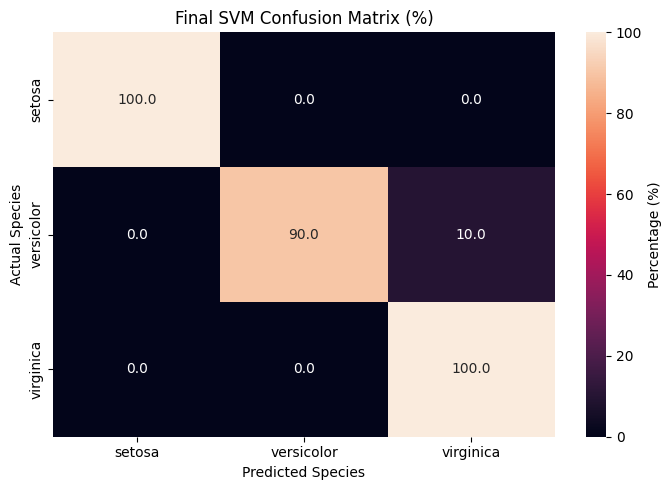

In [42]:
# ==========================================
# Step 29: Final SVM Confusion Matrix (%)
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix using final model
final_cm = confusion_matrix(y_test, final_pred)

# Convert to row-wise percentage
final_cm_percentage = (
    final_cm.astype(float)
    / final_cm.sum(axis=1)[:, np.newaxis]
    * 100
)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm_percentage,
    annot=True,
    fmt=".1f",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cbar_kws={"label": "Percentage (%)"}
)

plt.title("Final SVM Confusion Matrix (%)")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()
plt.show()

# Model Limitations

Although the final SVM model achieved 96.67% accuracy on the held-out test set, the dataset has only 150 samples and four numerical features. Therefore, the results may not generalize to larger or more diverse datasets.

The model should not be considered a production-ready flower classification system without testing it on additional real-world data.

Another limitation is that the model made one incorrect prediction, where a Versicolor sample was classified as Virginica. This indicates that some samples from these two species can have similar feature characteristics.

# Conclusion

In this project, machine learning models were developed to classify Iris flower species using four morphological features: sepal length, sepal width, petal length, and petal width.

A Dummy Classifier was used as a simple baseline, followed by Logistic Regression and Support Vector Machine (SVM). The original SVM achieved the best held-out test performance with 96.67% accuracy, 96.97% precision, 96.67% recall, and 96.66% F1-score.

Hyperparameter tuning was also performed using 5-fold cross-validation. Although the tuned SVM achieved 97.50% cross-validation accuracy, its held-out test accuracy was 93.33%. Therefore, the original SVM was selected as the final model based on its better performance on the unseen test set.

The final model correctly classified 29 out of 30 test samples. The only error was a Versicolor sample predicted as Virginica.